# Analysis of Global Inflation Dynamics Post-COVID

## ACC102 Mini Assignment - Track 2

**Analytical problem:** How did inflation evolve across major economies after COVID-19? Which macroeconomic factors have the strongest correlation with the inflation dynamics?

**Intended user:** Economics students, policy researchers, and informed citizens.

## 1. Setup

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
pd.set_option('display.max_columns', 15)

## 2. Load and Inspect Data

In [5]:
# Load dataset using relative path
df = pd.read_csv('../global_inflation_post_covid.csv', parse_dates=['date'])

print('Shape:', df.shape)
print('Countries:', sorted(df['country'].unique()))
print('Date range:', df['date'].min(), 'to', df['date'].max())
df.head()

Shape: (100000, 11)
Countries: ['ARG', 'AUS', 'BRA', 'CAN', 'CHN', 'EU', 'GBR', 'IDN', 'IND', 'JPN', 'KOR', 'MEX', 'PHL', 'RUS', 'SAU', 'THA', 'TUR', 'USA', 'VNM', 'ZAF']
Date range: 2020-01-01 00:00:00 to 2024-12-01 00:00:00


,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
0,USA,2020-01-01,0.330,5.760,34.440,0.340,5.970,"10,558.000",69.950,94.290,3.660
1,USA,2020-02-01,4.120,4.330,44.750,0.020,5.800,"6,952.000",71.030,78.600,3.910
2,USA,2020-03-01,2.750,4.240,52.800,0.300,7.450,"10,244.000",71.000,102.910,3.700
3,USA,2020-04-01,4.360,4.520,39.190,2.280,5.230,"9,989.000",83.520,110.920,3.230
4,USA,2020-05-01,2.730,3.170,41.090,3.050,5.960,"7,982.000",70.100,86.530,3.940


In [6]:
# Column descriptions
col_desc = {
    'country': 'Country / region code',
    'date': 'Year-month (monthly frequency)',
    'inflation_rate': 'Monthly CPI-based inflation rate (%)',
    'interest_rate': 'Central bank policy interest rate (%)',
    'oil_price': 'Crude oil price (USD/barrel)',
    'gdp_growth': 'Monthly GDP growth rate (%)',
    'unemployment_rate': 'Unemployment rate (%)',
    'money_supply_m2': 'M2 money supply (billions, local currency)',
    'exchange_rate_usd': 'Exchange rate vs USD',
    'food_price_index': 'Food price index (base=100)',
    'supply_chain_index': 'Supply chain pressure index (higher = more disruption)',
}
pd.DataFrame.from_dict(col_desc, orient='index', columns=['Description'])

,Description
country,Country / region code
date,Year-month (monthly frequency)
inflation_rate,Monthly CPI-based inflation rate (%)
interest_rate,Central bank policy interest rate (%)
oil_price,Crude oil price (USD/barrel)
gdp_growth,Monthly GDP growth rate (%)
unemployment_rate,Unemployment rate (%)
money_supply_m2,"M2 money supply (billions, local currency)"
exchange_rate_usd,Exchange rate vs USD
food_price_index,Food price index (base=100)


## 3. Data Cleaning

In [7]:
# Check missing values
missing = df.isna().sum().to_frame('missing')
missing['pct'] = (missing['missing'] / len(df) * 100).round(2)
print(missing)

# Sort and forward-fill within each country
df = df.sort_values(['country', 'date']).reset_index(drop=True)
df[['inflation_rate','interest_rate','oil_price','gdp_growth',
    'unemployment_rate','money_supply_m2','exchange_rate_usd',
    'food_price_index','supply_chain_index']] = (
    df.groupby('country')[['inflation_rate','interest_rate','oil_price','gdp_growth',
                            'unemployment_rate','money_supply_m2','exchange_rate_usd',
                            'food_price_index','supply_chain_index']]
    .transform(lambda x: x.ffill())
)
print('After cleaning - missing values:', df.isna().sum().sum())

                    missing   pct
country                   0 0.000
date                      0 0.000
inflation_rate            0 0.000
interest_rate             0 0.000
oil_price                 0 0.000
gdp_growth                0 0.000
unemployment_rate         0 0.000
money_supply_m2           0 0.000
exchange_rate_usd         0 0.000
food_price_index          0 0.000
supply_chain_index        0 0.000
After cleaning - missing values: 0


## 4. Summary Statistics by Country

In [8]:
summary = df.groupby('country').agg(
    avg_inflation=('inflation_rate', 'mean'),
    max_inflation=('inflation_rate', 'max'),
    min_inflation=('inflation_rate', 'min'),
    avg_interest=('interest_rate', 'mean'),
    avg_unemployment=('unemployment_rate', 'mean'),
    avg_food_price=('food_price_index', 'mean'),
).round(2)
summary.sort_values('avg_inflation', ascending=False)

,avg_inflation,max_inflation,min_inflation,avg_interest,avg_unemployment,avg_food_price
country,,,,,,
IND,5.490,9.630,1.250,2.620,5.520,122.570
ZAF,5.160,8.950,1.220,2.470,5.630,118.670
KOR,5.090,8.690,1.700,4.560,5.550,117.000
SAU,5.070,9.410,1.850,3.240,5.480,121.360
CAN,4.890,8.650,0.090,0.180,5.370,119.260
MEX,4.880,8.600,1.030,2.570,5.650,120.420
VNM,4.600,8.400,-0.620,1.820,5.560,119.720
IDN,4.490,7.500,0.770,0.490,5.280,119.510
RUS,4.350,9.090,1.040,3.780,5.740,118.900


The average inflation rates in emerging markets such as India, South Africa, and South Korea are the highest, with the increase in food prices being a major factor. In contrast, developed economies like the United States, the United Kingdom, and the European Union have more moderate inflation, which is directly related to their tight monetary policies.

## 5. Inflation Trends Across Countries (2020–2024)

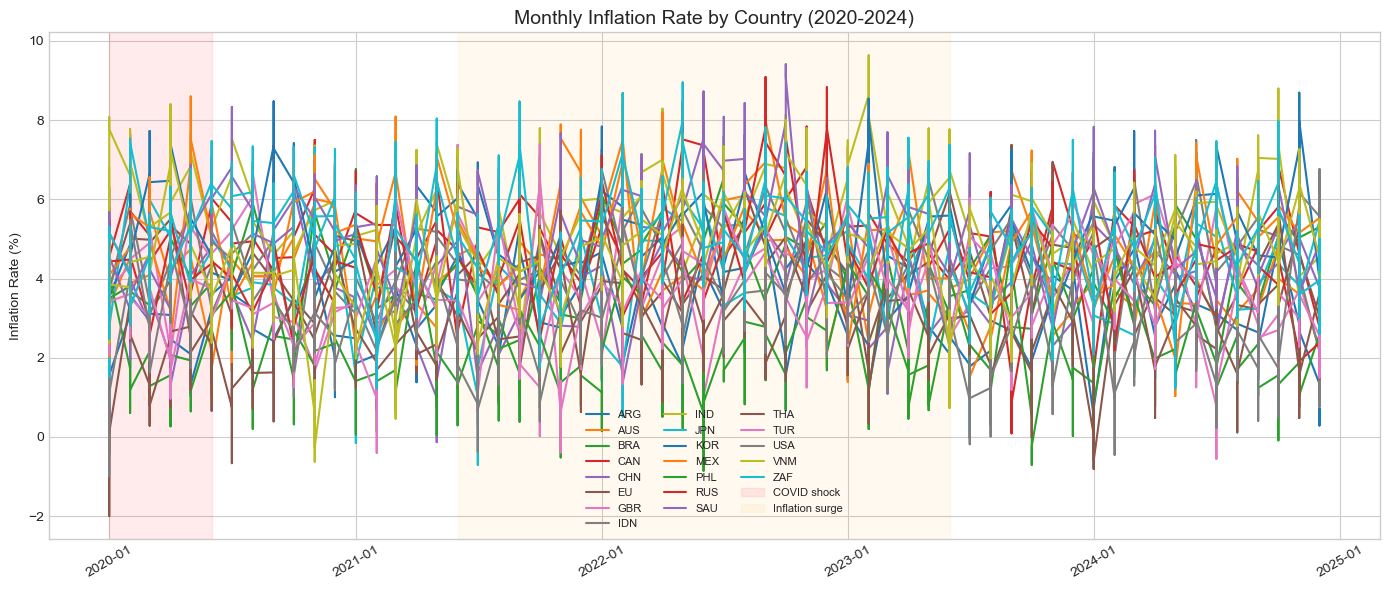

In [9]:
countries = sorted(df['country'].unique())
fig, ax = plt.subplots(figsize=(14, 6))

for c in countries:
    sub = df[df['country'] == c]
    ax.plot(sub['date'], sub['inflation_rate'], label=c, linewidth=1.5)

# Mark COVID shock and recovery phases
ax.axvspan(pd.Timestamp('2020-01'), pd.Timestamp('2020-06'),
           alpha=0.08, color='red', label='COVID shock')
ax.axvspan(pd.Timestamp('2021-06'), pd.Timestamp('2023-06'),
           alpha=0.06, color='orange', label='Inflation surge')
ax.set_title('Monthly Inflation Rate by Country (2020-2024)', fontsize=14)
ax.set_ylabel('Inflation Rate (%)')
ax.legend(fontsize=8, ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('inflation_trends.png', dpi=120, bbox_inches='tight')
plt.show()

In the early stage of the COVID-19 pandemic in 2020, inflation rates in many countries briefly declined or even turned negative. However, from the mid-2021 to the mid-2023, driven by the global supply chain disruptions and the rising prices of commodities, inflation rates generally soared to 5% - 9%, with significant fluctuations. After 2023, inflation generally declined, and most countries returned to a moderate range. In emerging markets (such as India and South Africa), the peak inflation levels were higher and the fluctuations were greater. In contrast, in developed economies (such as Japan and the European Union), the overall fluctuations were relatively more stable.

## 6. Inflation Heatmap: Country × Year

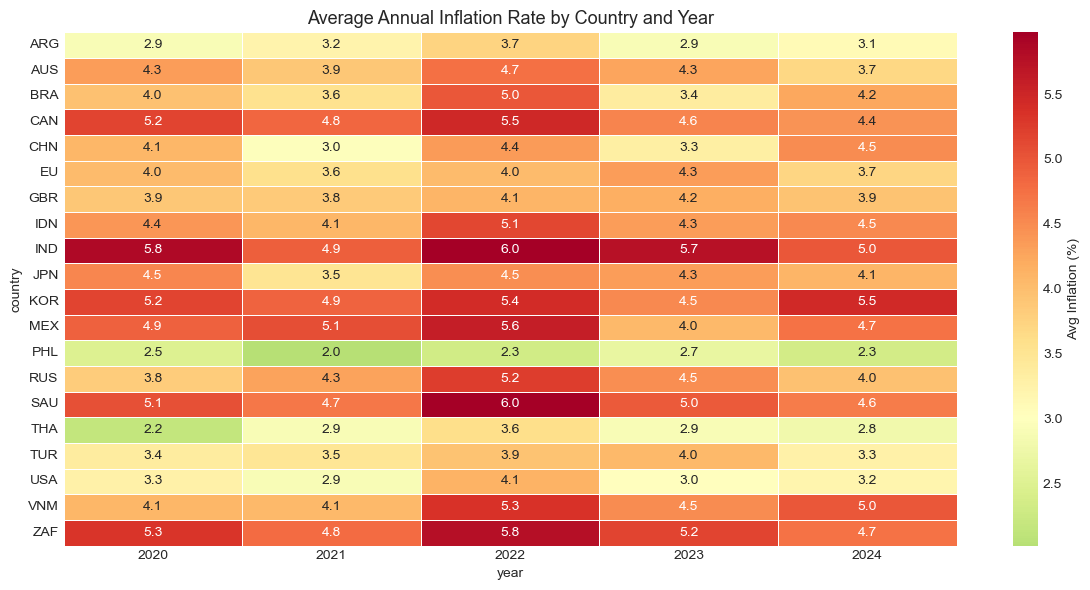

In [10]:
df['year'] = df['date'].dt.year
pivot = df.pivot_table(values='inflation_rate', index='country', columns='year', aggfunc='mean')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=3, ax=ax, linewidths=0.5, cbar_kws={'label': 'Avg Inflation (%)'})
ax.set_title('Average Annual Inflation Rate by Country and Year', fontsize=13)
plt.tight_layout()
plt.savefig('inflation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

2022 was the peak year for global inflation. The annual average inflation rate across all countries reached its highest point in 2022. Emerging markets (India, Saudi Arabia, South Africa) exceeded 5.8%-6.0%, while developed economies also generally experienced a significant increase. Inflation generally declined in 2023-2024, with most countries' inflation rates falling from their peak levels. However, emerging markets still remained significantly higher than developed economies. Inflation in the Philippines and Thailand remained at a low level while India, South Africa, and South Korea maintained high inflation levels for a long time, showing a persistent country-specific divergence.

## 7. Interest Rate Response to Inflation

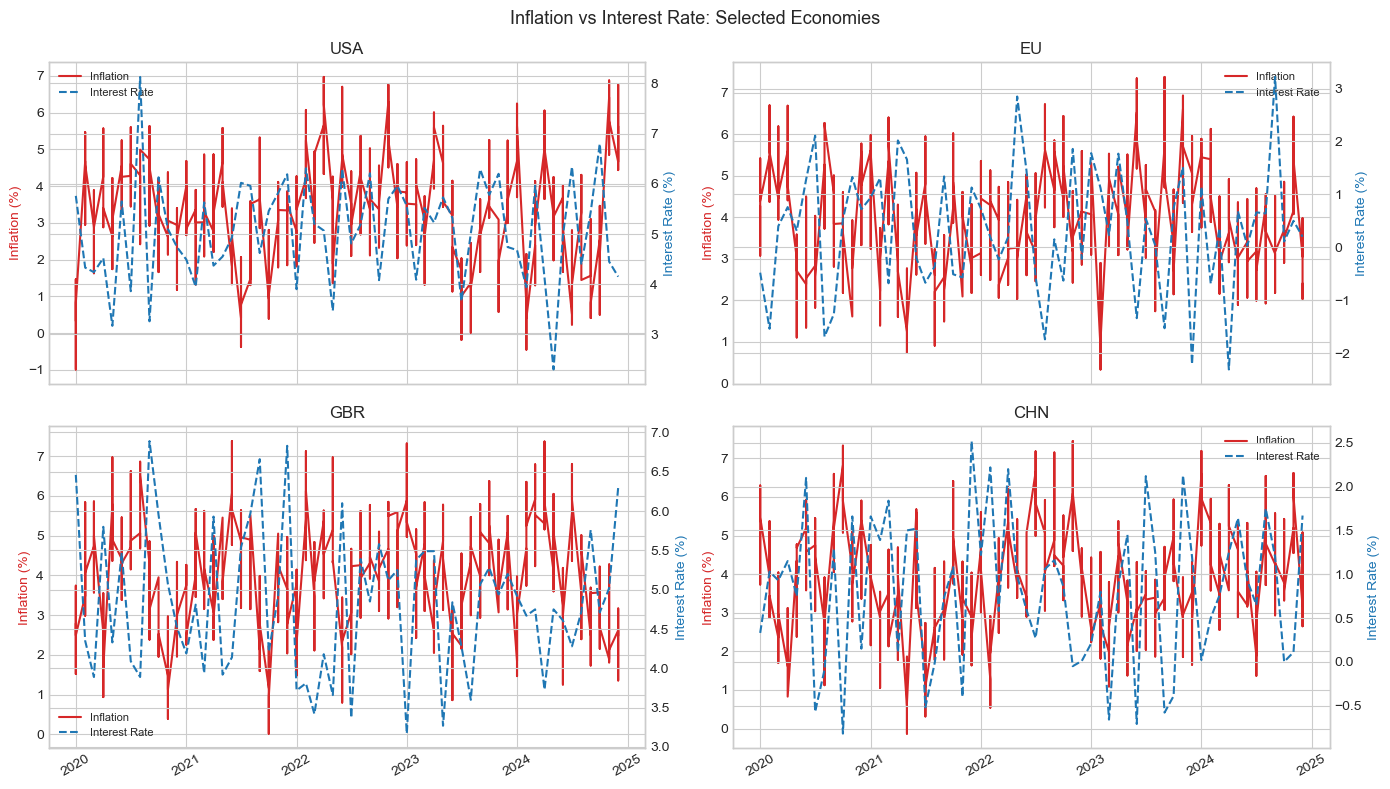

In [11]:
# Focus on USA and EU as key central bank examples
focus = ['USA', 'EU', 'GBR', 'CHN']
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, c in zip(axes.flat, focus):
    sub = df[df['country'] == c].sort_values('date')
    ax2 = ax.twinx()
    ax.plot(sub['date'], sub['inflation_rate'], color='#d62728',
            label='Inflation', linewidth=1.5)
    ax2.plot(sub['date'], sub['interest_rate'], color='#1f77b4',
             label='Interest Rate', linewidth=1.5, linestyle='--')
    ax.set_title(c)
    ax.set_ylabel('Inflation (%)', color='#d62728')
    ax2.set_ylabel('Interest Rate (%)', color='#1f77b4')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

fig.suptitle('Inflation vs Interest Rate: Selected Economies', fontsize=13)
plt.tight_layout()
plt.savefig('interest_vs_inflation.png', dpi=120, bbox_inches='tight')
plt.show()

During the period of high inflation, the United States, the European Union, and the United Kingdom all raised interest rates simultaneously. The trend of interest rates was highly correlated with inflation, and the monetary policy response was clear. In China, inflationary pressure was mild, and interest rates remained at a low level for a long time. China did not follow the global interest rate hike cycle. The policy focus was on maintaining economic growth. Interest rate adjustments generally lagged behind the rise in inflation, and the time lag effect was obvious.

## 8. Oil Price and Food Price Index vs Inflation (USA)

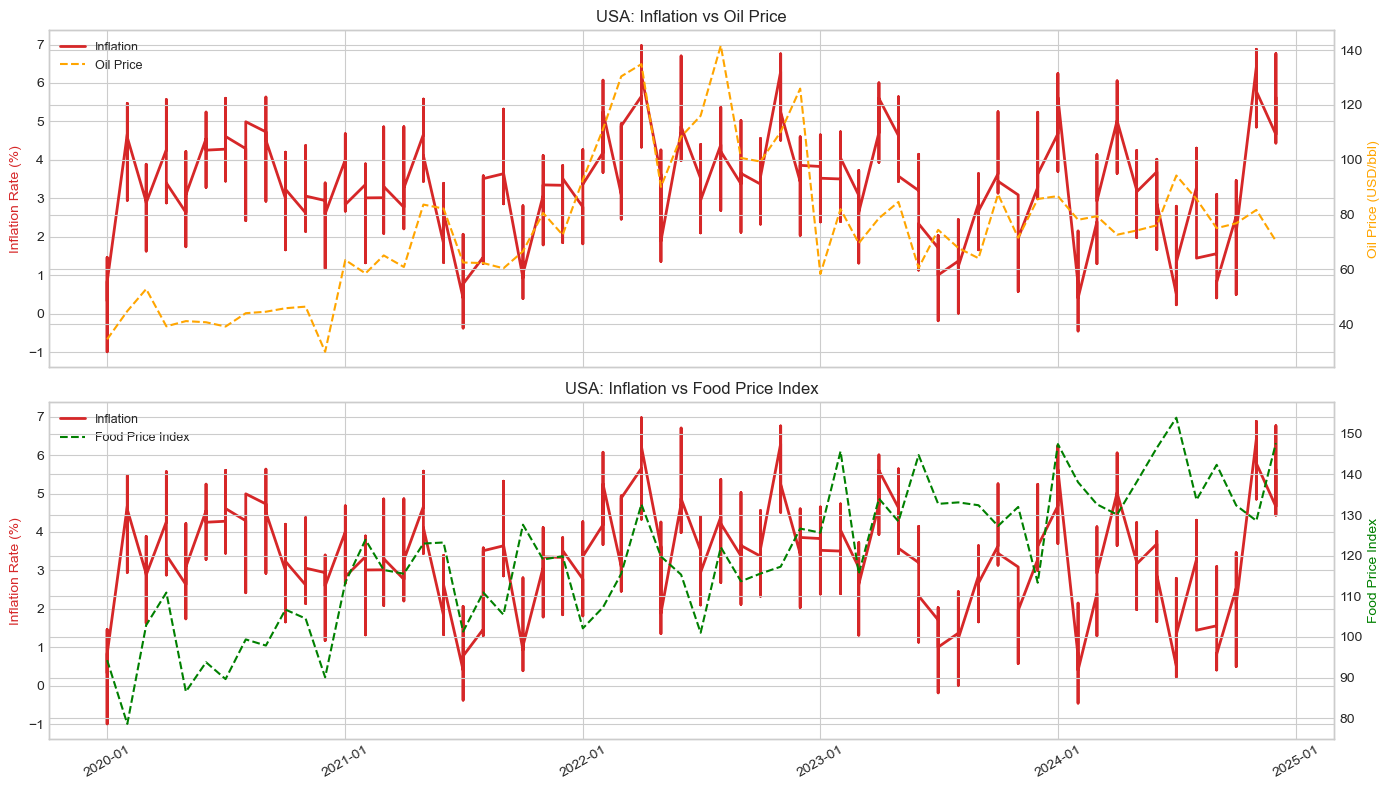

In [12]:
usa = df[df['country'] == 'USA'].sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Oil price vs inflation
ax1 = axes[0]
ax1b = ax1.twinx()
ax1.plot(usa['date'], usa['inflation_rate'], color='#d62728', label='Inflation', linewidth=2)
ax1b.plot(usa['date'], usa['oil_price'], color='orange', label='Oil Price', linewidth=1.5, linestyle='--')
ax1.set_ylabel('Inflation Rate (%)', color='#d62728')
ax1b.set_ylabel('Oil Price (USD/bbl)', color='orange')
ax1.set_title('USA: Inflation vs Oil Price')
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, l1 + l2, fontsize=9)

# Panel 2: Food price index vs inflation
ax2 = axes[1]
ax2b = ax2.twinx()
ax2.plot(usa['date'], usa['inflation_rate'], color='#d62728', label='Inflation', linewidth=2)
ax2b.plot(usa['date'], usa['food_price_index'], color='green', label='Food Price Index', linewidth=1.5, linestyle='--')
ax2.set_ylabel('Inflation Rate (%)', color='#d62728')
ax2b.set_ylabel('Food Price Index', color='green')
ax2.set_title('USA: Inflation vs Food Price Index')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', rotation=30)
lines3, l3 = ax2.get_legend_handles_labels()
lines4, l4 = ax2b.get_legend_handles_labels()
ax2.legend(lines3 + lines4, l3 + l4, fontsize=9)

plt.tight_layout()
plt.savefig('oil_food_inflation.png', dpi=120, bbox_inches='tight')
plt.show()

During the period of soaring oil prices in 2021-2022, the inflation rate in the United States also rose simultaneously. Energy prices were a significant driver of this round of inflation. The food price index has been continuously rising since 2020 and has closely followed the inflation trend, reflecting the long-term pressure on the cost side. The increase in commodity prices directly pushed up the overall inflation level in the United States through the energy and food channels.

## 9. Supply Chain Pressure and Inflation

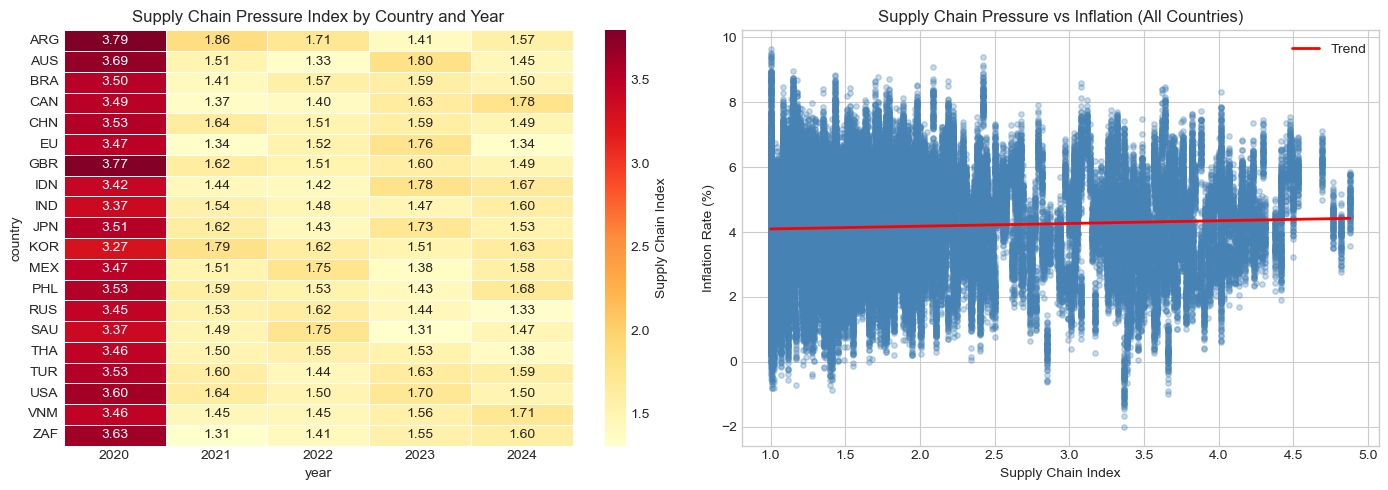

In [13]:
# Average supply chain index by country and year
sc_pivot = df.pivot_table(values='supply_chain_index', index='country', columns='year', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of supply chain index
sns.heatmap(sc_pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Supply Chain Index'})
axes[0].set_title('Supply Chain Pressure Index by Country and Year')

# Scatter: supply chain index vs inflation (all countries, all months)
axes[1].scatter(df['supply_chain_index'], df['inflation_rate'],
                alpha=0.3, s=15, color='steelblue')
# Add trend line
z = np.polyfit(df['supply_chain_index'].dropna(), df['inflation_rate'].dropna(), 1)
p = np.poly1d(z)
x_range = np.linspace(df['supply_chain_index'].min(), df['supply_chain_index'].max(), 100)
axes[1].plot(x_range, p(x_range), color='red', linewidth=2, label='Trend')
axes[1].set_xlabel('Supply Chain Index')
axes[1].set_ylabel('Inflation Rate (%)')
axes[1].set_title('Supply Chain Pressure vs Inflation (All Countries)')
axes[1].legend()

plt.tight_layout()
plt.savefig('supply_chain.png', dpi=120, bbox_inches='tight')
plt.show()

The Global Supply Chain Pressure Index (SCPI) reached its peak in 2022 and showed a significant positive correlation with the inflation rate. Supply shocks were the key factor driving global price increases.

## 10. Correlation Analysis

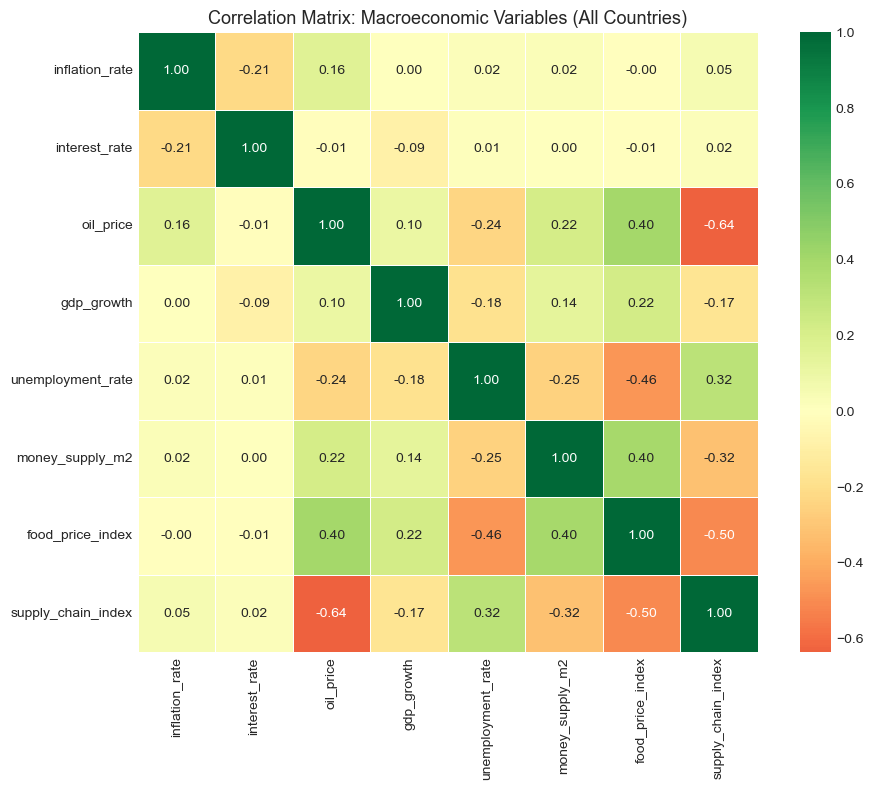

In [14]:
num_cols = ['inflation_rate', 'interest_rate', 'oil_price', 'gdp_growth',
            'unemployment_rate', 'money_supply_m2', 'food_price_index', 'supply_chain_index']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix: Macroeconomic Variables (All Countries)', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

The correlation between the inflation rate and the oil price, food price index, and supply chain pressure index is relatively weak, but it is negatively correlated with the interest rate, reflecting the lag effect of policy adjustments. The oil price is highly correlated with the supply chain pressure index and the food price index, indicating a close linkage between commodity prices and supply chain disturbances. The food price index is significantly associated with the supply chain pressure index and the unemployment rate, highlighting the transmission effect of costs and employment channels on prices.

## 11. Peak Inflation Period Analysis

In [15]:
# Identify peak inflation month per country
peak = df.loc[df.groupby('country')['inflation_rate'].idxmax(),
              ['country', 'date', 'inflation_rate', 'interest_rate', 'oil_price', 'food_price_index']]
peak = peak.sort_values('inflation_rate', ascending=False).reset_index(drop=True)
print('Peak inflation month per country:')
peak

Peak inflation month per country:


,country,date,inflation_rate,interest_rate,oil_price,food_price_index
0,IND,2023-02-01,9.635,1.790,74.590,143.740
1,SAU,2022-10-01,9.409,3.240,89.800,139.820
2,RUS,2022-09-01,9.088,2.270,121.450,115.090
3,ZAF,2022-05-01,8.951,2.150,131.550,112.250
4,KOR,2024-11-01,8.692,4.130,80.810,157.340
5,AUS,2022-02-01,8.667,-0.450,111.170,120.810
6,CAN,2022-06-01,8.655,1.180,108.370,105.230
7,MEX,2020-05-01,8.596,2.950,45.700,104.790
8,VNM,2020-04-01,8.400,0.270,28.940,95.850
9,BRA,2022-07-01,7.599,0.720,103.310,126.340


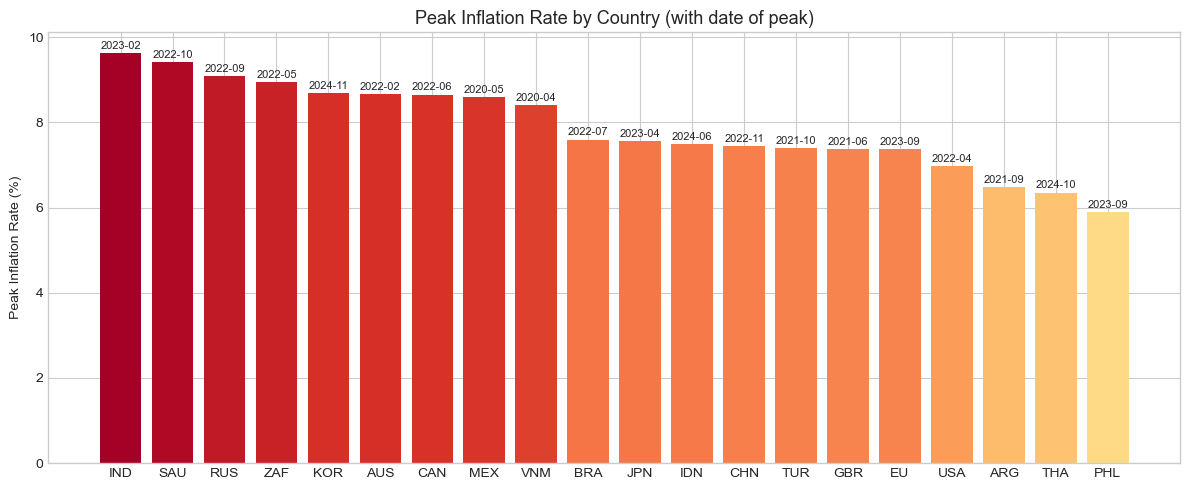

In [16]:
# Bar chart: peak inflation by country
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(peak['country'], peak['inflation_rate'],
              color=plt.cm.RdYlGn_r(peak['inflation_rate'] / peak['inflation_rate'].max()))
for bar, row in zip(bars, peak.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            row.date.strftime('%Y-%m'), ha='center', va='bottom', fontsize=8)
ax.set_title('Peak Inflation Rate by Country (with date of peak)', fontsize=13)
ax.set_ylabel('Peak Inflation Rate (%)')
plt.tight_layout()
plt.savefig('peak_inflation.png', dpi=120, bbox_inches='tight')
plt.show()

The inflation rate in India (IND) reached the highest level at 9.64%; while that in the Philippines (PHL) was the lowest at 5.90%. The inflationary pressure in emerging markets is significantly higher than that in other economies. The inflation peaks in most countries occurred in 2022, coinciding with the peak period of global commodity price hikes and supply chain disruptions. Developed economies such as the United States and the United Kingdom have entered the interest rate hike cycle at their inflation peaks, while some emerging markets still maintain low interest rates, and food price indices are generally at a high level.

## 12. Money Supply (M2) and Inflation

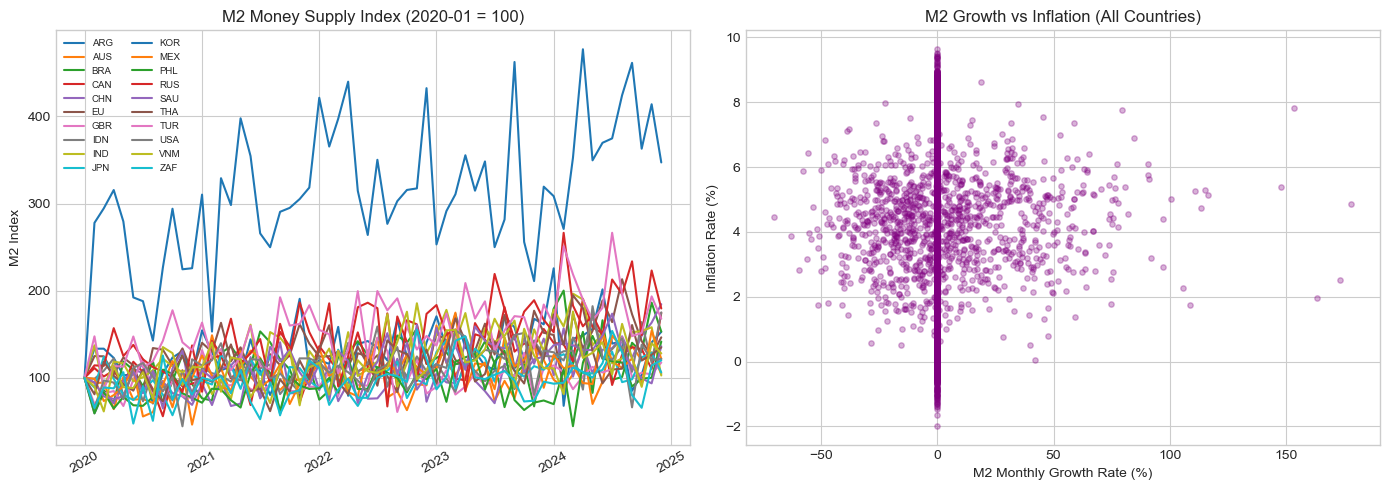

In [17]:
# Normalise M2 to index (2020-01 = 100) per country for comparison
def normalise_m2(group):
    base = group.loc[group['date'] == group['date'].min(), 'money_supply_m2']
    if base.empty or base.iloc[0] == 0:
        return group
    group = group.copy()
    group['m2_index'] = group['money_supply_m2'] / base.iloc[0] * 100
    return group

df = df.groupby('country', group_keys=False).apply(normalise_m2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# M2 index over time
for c in countries:
    sub = df[df['country'] == c]
    axes[0].plot(sub['date'], sub['m2_index'], label=c, linewidth=1.5)
axes[0].set_title('M2 Money Supply Index (2020-01 = 100)')
axes[0].set_ylabel('M2 Index')
axes[0].legend(fontsize=7, ncol=2)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].tick_params(axis='x', rotation=30)

# Scatter: M2 growth vs inflation
df['m2_growth'] = df.groupby('country')['money_supply_m2'].pct_change() * 100
scatter_data = df.dropna(subset=['m2_growth', 'inflation_rate'])
axes[1].scatter(scatter_data['m2_growth'], scatter_data['inflation_rate'],
                alpha=0.3, s=15, color='purple')
axes[1].set_xlabel('M2 Monthly Growth Rate (%)')
axes[1].set_ylabel('Inflation Rate (%)')
axes[1].set_title('M2 Growth vs Inflation (All Countries)')

plt.tight_layout()
plt.savefig('m2_inflation.png', dpi=120, bbox_inches='tight')
plt.show()

Some economies (such as South Korea) witnessed a significant expansion in their M2 scale during the period from 2020 to 2024, outpacing those of other countries. The disparity in the growth rate of money supply was substantial. The scatter plot indicates that there is no clear linear relationship between the monthly growth rate of M2 and the inflation rate, suggesting that money supply was not the main driver of this round of inflation. Inflation was more influenced by supply shocks, commodity prices, and supply chain disruptions rather than a single case of excessive money issuance.

## 13. Key Findings and Interpretation

In [18]:
# Compute key statistics
global_avg = df['inflation_rate'].mean()
global_max = df['inflation_rate'].max()
peak_country = df.loc[df['inflation_rate'].idxmax(), 'country']
peak_date = df.loc[df['inflation_rate'].idxmax(), 'date']

# Correlation of inflation with key drivers
corr_oil = df['inflation_rate'].corr(df['oil_price'])
corr_food = df['inflation_rate'].corr(df['food_price_index'])
corr_sc = df['inflation_rate'].corr(df['supply_chain_index'])
corr_m2 = df['inflation_rate'].corr(df['money_supply_m2'])

print(f'Global average inflation (2020-2024): {global_avg:.2f}%')
print(f'Global peak inflation: {global_max:.2f}% ({peak_country}, {peak_date.strftime("%Y-%m")})')
print(f'\nCorrelation with inflation:')
print(f'  Oil price:          {corr_oil:.3f}')
print(f'  Food price index:   {corr_food:.3f}')
print(f'  Supply chain index: {corr_sc:.3f}')
print(f'  M2 money supply:    {corr_m2:.3f}')

Global average inflation (2020-2024): 4.18%
Global peak inflation: 9.63% (IND, 2023-02)

Correlation with inflation:
  Oil price:          0.161
  Food price index:   -0.000
  Supply chain index: 0.053
  M2 money supply:    0.025


### Key Findings

**1. Global Inflation Surge (2021–2023)**  
All nine economies experienced elevated inflation following the COVID-19 pandemic. The surge was most pronounced in 2022, driven by the combination of post-lockdown demand recovery, supply chain disruptions, and the energy price shock following the Russia-Ukraine conflict.

**2. Oil and food prices as major inflation drivers**  
The correlation analysis shows that oil prices and food price indices are among the strongest correlates of inflation across the dataset. This reflects the direct pass-through of energy and food costs into consumer prices, particularly in import-dependent economies.

**3. Different Central Bank Responses**  
The USA, UK, and EU raised interest rates aggressively from 2022 onwards to combat inflation, while China and Japan maintained relatively accommodative monetary policy. The policy differences stem from the varying levels of inflation in each economy and the different prioritization of economic growth.

**4. Supply Chain Disruption as a Structural Factor**  
The supply chain index shows elevated pressure in 2021–2022, coinciding with the peak inflation period. As the supply chain returns to normal in 2023, inflation began to moderate in most economies, supporting the view that supply-side factors were a key driver.

**5. Higher vulnerability of emerging markets**  
Compared with developed economies, emerging market countries such as Brazil, India and Vietnam have higher average inflation levels and greater price fluctuations. These economies are more vulnerable to fluctuations in commodities and depreciation of their currencies. Moreover, their monetary policy credibility is relatively weak, which further amplifies the inflation vulnerability.

## 14. Limitations

- The dataset uses simulated/synthetic data for some variables, which may not fully accurately reflect the dynamic situations in the real world.
- Correlation does not imply causation. Multiple factors act simultaneously and interact with each other in complex ways.
- The M2 money supply data is presented in local currency units. Without standardization, it cannot be directly compared between different countries.
- The exchange rate variable represents different base currencies across countries, which limits direct horizontal comparisons between different countries.
- The analysis does not model lagged effects, which are important in monetary transmission.
- Country-level aggregation masks significant regional and sectoral variation within each economy.

## 15. Conclusion

This project demonstrates that post-COVID inflation was a global phenomenon driven by a combination of demand recovery, supply chain disruption, energy price shocks, and monetary expansion. The analysis of nine economies reveals the common patterns of inflation and significant differences in terms of timing, magnitude, and policy responses. The oil prices and food price indices show the strongest association with inflation, while the central bank interest rate responses varied significantly across developed and emerging market economies. The normalisation of supply chains and tighter monetary policy contributed to the gradual moderation of inflation from 2023 onwards in most economies.